<a href="https://colab.research.google.com/github/kanebako-s/olist-data-analysis/blob/main/Kaggle_Olist_analysis_v2.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olistのリピート率改善に向けた原因特定と改善提案。

In [1]:
# --- ライブラリのインポート ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# --- グラフの見た目を整える ---
sns.set(style="whitegrid") # グラフにグリッド（網掛け）を出して見やすくする
plt.rcParams["figure.figsize"] = (10, 6) # グラフの基本サイズを少し大きくする

# --- データの表示設定 ---
pd.options.display.max_columns = None # 列数が多い時、省略（...）せずに全部表示する
pd.set_option('display.float_format', '{:.2f}'.format) # 小数点以下を2桁に固定して見やすくする

# --- 日本語化（重要！） ---
!pip install japanize-matplotlib
import japanize_matplotlib # これでグラフの日本語が「□」にならずに済む

# --- Worldcloudのインストール ---
!pip install wordcloud
from wordcloud import WordCloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 23.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=0e966f5dab550e97ee4ae8e3776c34b526fae49849b651ab40ce6c100dac6536
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


# Executive Summary

# Data Preparation

** データの統合と整合性 **

 ここでは、分析の土台となるデータセットの作成を行います。


* データの整合性 : 分析に正確性を期すために1注文=1行になるように集計を行いました。単純な結合の場合11万9千件にまで増殖してしまいますが、重複を排除することで信頼性のあるデータにしています。

* 変数の作成 : リピート分析を主眼に置いているため注文合計金額（total_item_price）を作成することでリピート率の改善が売り上げにどれだけの影響が出るのか正しく評価できるようにしました。

In [2]:
from pathlib import Path

# ファイルの読み込み。
BASE_DIR = Path('/content/drive/MyDrive/Olist_Dateanalist_Learning') # ファイルの読み込みが自分専用になっている。あとで直しやすいようにしている。

df_customers = pd.read_csv(BASE_DIR / 'olist_customers_dataset.csv')
df_orders = pd.read_csv(BASE_DIR / 'olist_orders_dataset.csv')
df_order_reviews = pd.read_csv(BASE_DIR / 'olist_order_reviews_dataset.csv')
df_order_items = pd.read_csv(BASE_DIR / 'olist_order_items_dataset.csv')
df_products = pd.read_csv(BASE_DIR / 'olist_products_dataset.csv')
df_order_payments = pd.read_csv(BASE_DIR / 'olist_order_payments_dataset.csv')

# テーブルの結合。
# 分析に必要な列だけを定義。
customer_cols = ['customer_id', 'customer_unique_id']
item_cols = ['order_id', 'product_id', 'seller_id', 'price']
product_cols = ['product_id', 'product_category_name', 'product_photos_qty', 'product_description_lenght']
timestamps_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_creation_date', 'review_answer_timestamp']

# 集計で重複が発生しないように注文ごとにまとめる。
# マージする前に、注文ごとの合計支払額にまとめてしまう。
df_payments_sum = df_order_payments.groupby('order_id')['payment_value'].sum().reset_index()

# df_order_items を注文単位で集計。
df_items_sum = df_order_items.groupby('order_id').agg({
    'product_id': 'first',  # 最も高い商品のIDを1つだけ取る（これでdf_productsと繋がる！）
    'seller_id': 'first',   # その商品のセラーを取る
    'price': 'sum',         # 価格は「合計金額」として残す
}).reset_index()

# カラム名を分かりやすく変えておく。
df_items_sum = df_items_sum.rename(columns={'price': 'total_item_price'})

# レビューを注文IDごとに1件に絞る（最新の投稿時間から最終的なレビューコメントを代表値として残す）
df_reviews_unique = (
    df_order_reviews
    .sort_values('review_creation_date', ascending=False)
    .drop_duplicates('order_id')
)

# メソッドチェーンでマージ。
df_final = (
    df_orders
    .merge(df_customers[customer_cols], on='customer_id', how='left')
    .merge(df_items_sum, on='order_id', how='left')
    .merge(df_reviews_unique, on='order_id', how='left')
    .merge(df_products[product_cols], on='product_id', how='left')
    .merge(df_payments_sum, on='order_id', how='left')
)

# ループで一気に日付型に変換。
for col in timestamps_cols:
    df_final[col] = pd.to_datetime(df_final[col])

# df_final.shape
df_orders.shape

(99441, 8)

結果 : 行数が一致したことを確認。

分析方針 : 最初に売上向上を目的としてリピート率改善に着目する。まずはOlist全体のリピート率を把握し問題点の仮説を立てる。

In [3]:
df_final.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,product_id,seller_id,total_item_price,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name,product_photos_qty,product_description_lenght,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,a54f0611adc9ed256b57ede6b6eb5114,4.00,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,utilidades_domesticas,4.00,268.00,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,8d5266042046a06655c8db133d120ba5,4.00,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,perfumaria,1.00,178.00,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,e73b67b67587f7644d5bd1a52deb1b01,5.00,NaN,NaN,2018-08-18,2018-08-22 19:07:58,automotivo,1.00,232.00,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,359d03e676b3c069f62cadba8dd3f6e8,5.00,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58,pet_shop,3.00,468.00,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,e50934924e227544ba8246aeb3770dd4,5.00,NaN,NaN,2018-02-17,2018-02-18 13:02:51,papelaria,4.00,316.00,28.62


In [4]:
# Olist全体のリピート率の把握（同一のcustomer_unique_idで2回以上注文しているか）
repeat_counts = df_final.groupby('customer_unique_id')['order_id'].nunique()
repeat_rate = (repeat_counts > 1).sum() / len(repeat_counts) * 100

print(f"Olist全体のリピート率: {repeat_rate:.2f}%")

Olist全体のリピート率: 3.12%


結果 : 普通のECモールならリピート率は20~30%、もし消耗品以外の商品を扱っていたとしても約3%は低すぎる。リピート率の改善は喫緊の課題であることが確認できた。

注意点 : 2016年〜2018年の全データを用いているため、初期の顧客ほどリピートするチャンスがあった点に留意が必要。

** 分析方針 **

全体リピート率（3.12%）の低さが、「商材の特性（買い替えサイクルの長さ）」に起因するものなのか、あるいは「サービス体験の欠陥」によるものなのかを切り分けるため、売上のカテゴリー構成を可視化しました。

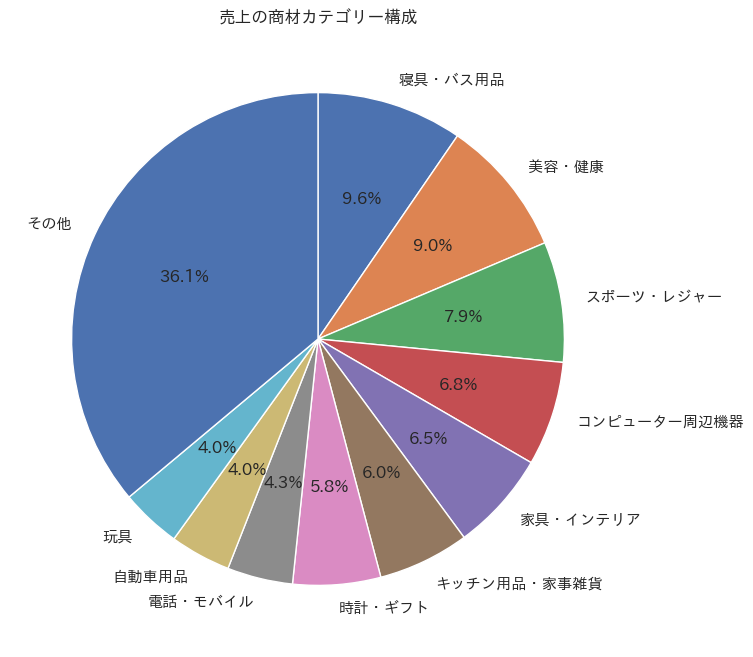

In [5]:
# カテゴリー別の注文数をカウント
category_counts = df_final['product_category_name'].value_counts()

# 上位10件を抽出し、残りを 'others' にまとめる
top_10 = category_counts.head(10)
others = pd.Series({'others': category_counts.iloc[10:].sum()})
plot_data = pd.concat([top_10, others])

# カテゴリー名を日本語に置換する。
category_mapping = {
    'cama_mesa_banho': '寝具・バス用品',
    'beleza_saude': '美容・健康',
    'esporte_lazer': 'スポーツ・レジャー',
    'informatica_acessorios': 'コンピューター周辺機器',
    'moveis_decoracao': '家具・インテリア',
    'utilidades_domesticas': 'キッチン用品・家事雑貨',
    'relogios_presentes': '時計・ギフト',
    'telefonia': '電話・モバイル',
    'automotivo': '自動車用品',
    'brinquedos': '玩具',
    'others': 'その他',
}
labels_japanese = plot_data.index.map(category_mapping)

# 円グラフの作成
plt.figure(figsize=(10, 8))
plt.pie(plot_data, labels=labels_japanese, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title('売上の商材カテゴリー構成')
plt.show()

** 分析結果に対する洞察 **

本グラフから、以下の2つの相反する要因が混在していることが明らかになりました。

* 商材特性によるリピート抑制要因 : 「寝具・バス用品（9.6%）」「家具・インテリア（6.5%）」といった耐久消費財が上位を占めています。これらの商材は本質的に購入頻度が低く、全体のリピート率を押し下げる構造的な要因となっていることが確認できました。

* リピート創出の潜在的な機会（ポテンシャル） : 一方で、「美容・健康（9.0%）」「キッチン用品・家事雑貨（6.0%）」は、本来であれば定期的な補充買い（リピート）が期待されるカテゴリーです。また、「その他（36.1%）」の中にも多くの消耗品が含まれていると推測されます。

** 結論と次ステップへの仮説 **

3.12%という低数値の一部は耐久消費財という商材構成に由来するものの、「美容・健康」や「家事雑貨」といったリピート推奨商材が上位にある中でこの数値に留まっている点は、ビジネス上の大きな機会損失を示唆しています。

したがって、【リピートが期待される商材を買った顧客さえも、二度目の購入を避けている（＝運営上の課題がある）】という仮説を立て、次は「美容・健康」「キッチン用品・家事雑貨」カテゴリーに特化したリピート率の深掘り調査を行い、真の離脱原因を特定します。

In [6]:
# 1. '美容・健康' カテゴリーのデータのみを抽出
df_beauty = df_final[df_final['product_category_name'] == 'beleza_saude']

# 2. その中での顧客ごとの注文回数をカウント
repeat_counts_beauty = df_beauty.groupby('customer_unique_id')['order_id'].nunique()

# 3. リピート率を算出
repeat_rate_beauty = (repeat_counts_beauty > 1).sum() / len(repeat_counts_beauty) * 100

print(f"美容・健康カテゴリーのリピート率: {repeat_rate_beauty:.2f}%")

美容・健康カテゴリーのリピート率: 1.75%


In [7]:
# 1. 'キッチン用品・家事雑貨' カテゴリーのデータのみを抽出
df_goods = df_final[df_final['product_category_name'] == 'utilidades_domesticas']

# 2. その中での顧客ごとの注文回数をカウント
repeat_counts_goods = df_goods.groupby('customer_unique_id')['order_id'].nunique()

# 3. リピート率を算出
repeat_rate_goods = (repeat_counts_goods > 1).sum() / len(repeat_counts_goods) * 100

print(f"キッチン用品・家事雑貨カテゴリーのリピート率: {repeat_rate_goods:.2f}%")

キッチン用品・家事雑貨カテゴリーのリピート率: 1.04%


** 分析結果に対する洞察 **

本分析の結果、リピートポテンシャルの高い「美容・健康（1.75%）」や「家事雑貨（1.04%）」のリピート率が、全体平均を大きく下回るという異常値が判明しました。

これにより、リピート率低迷の真因は「商材の特性」ではなく、「一度購入した顧客を失望させる、顧客体験に問題があること」の証拠と言えます。

** 分析方針 **

次は、この「失望」の正体を突き止めるべく「特定の悪質セラー」とそのセラーが扱う「商品カテゴリー」の関係性へと焦点を移します。まずは「悪質セラー」をどう定義するのか統計分析してセラーの特性を見ます。

In [8]:
# セラーごとの注文数をカウント（すでにseller_statsがある場合はそれを使います）
seller_order_counts = df_final.groupby('seller_id')['order_id'].nunique()

# 全セラーの平均・中央値・分布を確認
print("--- 全セラーの注文数統計 ---")
print(seller_order_counts.describe())

--- 全セラーの注文数統計 ---
count   3088.00
mean      31.95
std      104.09
min        1.00
25%        2.00
50%        6.00
75%       21.00
max     1844.00
Name: order_id, dtype: float64


** 悪質セラーの特定 **

注文数統計分析により、Olistには3088のセラーがいることを確認したが、注文数の中央値は6件に留まり大部分が小規模なセラーである事がわかった。

悪質セラーを定義する上で、ある程度継続して商売をしている事によりプラットフォームへの影響の大きい注文数の上位25%（21件以上）のセラーに焦点を当てて、その中で最低評価（スコア1）の割合が10%を超えるセラーを** 悪質セラー ** と定義する。

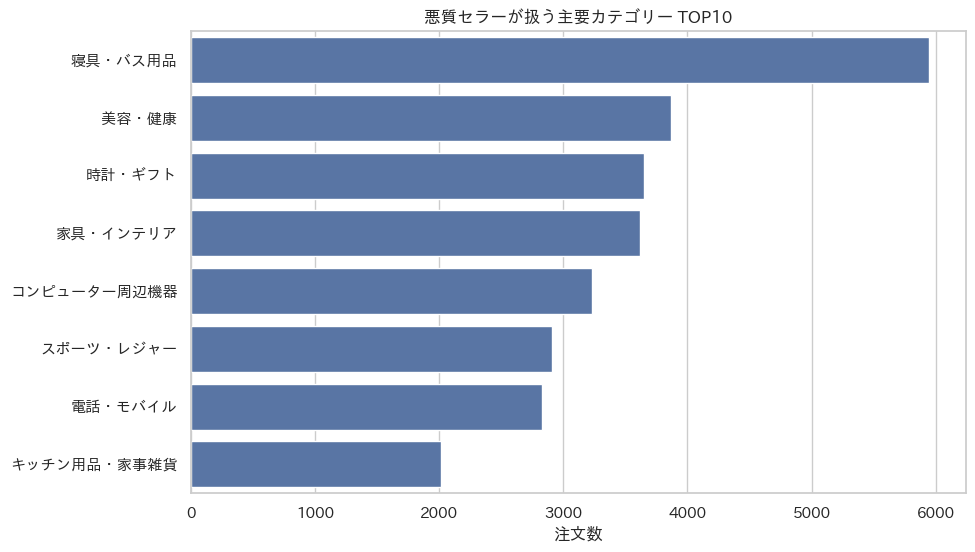

In [9]:
# 1. セラーごとの評価統計を算出
seller_stats = df_final.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'),
    avg_score=('review_score', 'mean'),
    bad_reviews=('review_score', lambda x: (x == 1).sum())
).reset_index()

# 2. 悪質/良質フラグの付与
seller_stats['bad_rate'] = seller_stats['bad_reviews'] / seller_stats['total_orders']
seller_stats['seller_type'] = 'Standard'
seller_stats.loc[(seller_stats['bad_rate'] > 0.1) & (seller_stats['total_orders'] >= 21), 'seller_type'] = 'Bad'
seller_stats.loc[(seller_stats['avg_score'] >= 4.5) & (seller_stats['total_orders'] >= 21), 'seller_type'] = 'Good'

# 3. 元のデータに紐付け
df_seller_analysis = pd.merge(df_final, seller_stats[['seller_id', 'seller_type']], on='seller_id', how='left')

# 4. 悪質セラーが扱うカテゴリーの可視化（上位10件）
bad_seller_categories = df_seller_analysis[df_seller_analysis['seller_type'] == 'Bad']['product_category_name'].value_counts().head(10)

# 悪質セラーが扱う主要カテゴリー TOP10 の可視化。
plt.figure(figsize=(10, 6))
sns.barplot(x=bad_seller_categories.values, y=bad_seller_categories.index.map(category_mapping))
plt.title('悪質セラーが扱う主要カテゴリー TOP10')
plt.xlabel('注文数')
plt.ylabel('')
plt.show()

** 分析結果からの洞察 **

* TOP10に絞ったはずが8つのカテゴリーしか出ていないことから悪質セラーはこの8つのカテゴリーに集中している事がわかる。

* これは悪質セラーがプラットフォーム全体に散らばっているのではなく、特定の市場（カテゴリー）に巣食っている事を示唆している。

** 改善提案 **

この８つの特定カテゴリーのセラー審査を厳格化することがコスト対効果が高いと考えられる。

** 分析方針 **

* 悪質セラーが特定地域に集中している可能性を考える。その場合配送業者に問題がある可能性が高い。

* 悪質セラーの不満の正体をテキストマイニングで抽出する。

* 悪質セラーが注文受諾してから発送するまでの時間のズレを確認する。

** データのノイズの排除 **

欠損値を確認してノイズとなるデータを特定する。

* 注文の承認時間（order_approved_at）が160件欠損していた。これは顧客が注文を承認する前にキャンセルしたということだから分析のノイズになり得るので除外します。

* 商品情報で写真掲載枚数（product_photos_qty）と商品説明（product_description_lenght）が2191件欠損していた。なんの情報もない商品の注文が2191件あったということは注文者はセラーに対して信頼していた可能性があります。また「思っていたのとは違った」という期待感のズレが発生している可能性があります。

  **

* （product_id, seller_id, total_item_price）の3つが775件欠損していた。これは注文承認時間の欠損より多く、注文承認はされたけどその後取引破棄になったものが600件くらいある事がわかります。

  ** 注文承認が降りた後取引破棄になったデータ **

  * 利用不可（unavailable）が603件もあることから、注文が承認されて届くのを待っていたら「在庫ないからキャンセル」と言われた。そんなシチュエーションが想像できます。

In [10]:
# 商品写真または説明文が欠損しているものを「情報なし」とする
df_final['is_no_info'] = df_final['product_photos_qty'].isnull() | df_final['product_description_lenght'].isnull()

# グループごとの平均レビュースコアを比較
info_comparison = df_final.groupby('is_no_info')['review_score'].mean()
print(info_comparison)

is_no_info
False   4.11
True    3.16
Name: review_score, dtype: float64


In [11]:
# 注文承認済み(not null) なのに、商品がない(null) 注文のステータスは？
print(df_final[df_final['order_approved_at'].notnull() & df_final['product_id'].isnull()]['order_status'].value_counts())

order_status
unavailable    603
canceled        23
invoiced         2
shipped          1
Name: count, dtype: int64


In [12]:
print(df_final.isnull().sum())

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                  160
order_delivered_carrier_date      1783
order_delivered_customer_date     2965
order_estimated_delivery_date        0
customer_unique_id                   0
product_id                         775
seller_id                          775
total_item_price                   775
review_id                          768
review_score                       768
review_comment_title             87889
review_comment_message           58667
review_creation_date               768
review_answer_timestamp            768
product_category_name             2191
product_photos_qty                2191
product_description_lenght        2191
payment_value                        1
is_no_info                           0
dtype: int64
